## Notebook Objectives
 - Load a model from the checkpoint file
 - plot the loss functions
 - plot the latent dimensions
 - GMM to latent dimensions
 - Analysis of RMSD, RMTD, Potential, Repulsion on:
   - Test Set
   - Decoded Test Set
   - GMM'ed Set

In [2]:
from typing import Optional, Any
import shutil, os, jax, flax, optax, json, matplotlib
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
from jax import random, numpy as jnp
#from pyscripts.Maths import Maths
#from pyscripts.NN_models import *
from flax import linen as nn
from flax.training import checkpoints, train_state
from flax import struct, serialization
import orbax.checkpoint
import mdtraj as md
#from pyscripts.AutoEncoder_Experiment import AutoEncoder_Experiment

2024-03-20 22:58:27.646390: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
class Experiment_Analyzer():
    def __init__(self, json_info, netcdf_fn, chkpt_fn):
        if type(json_info) is str:
            with open(json_info, 'r') as f:
                self.json_params = json.load(f)
        elif type(json_info) is dict:
            self.json_params = json_info
        else:
            raise Exception('json_info should be a string (to load the file) or dict (if the file is loaded already)')
        #Files
        fname_dcd = self.json_params["files"]["fname_dcd"]
        fname_prmtop = self.json_params["files"]["fname_prmtop"]
        save_dir = self.json_params["files"]["save_dir"]
        self.math = Maths(fname_prmtop)
        self.model_name = self.json_params["model"]["model_name"]
        model_dir = os.path.join(save_dir, f'{self.model_name}/')
        self.n_latents = self.json_params["training"]["arch"]["latent_dim"]
        activators = self.json_params["training"]["arch"]["activators"]
        layer_ops = self.json_params["training"]["arch"]["layer_ops"]
        dropout_rates = self.json_params["training"]["arch"]["dropout_rates"]
        self.batch_size = self.json_params["training"]["arch"]["batch_size"]
        learning_rate = self.json_params["training"]["arch"]["learning_rate"]
        test_slice = self.json_params["training"]["data"]["test_slice"]
        rng_key = self.json_params["training"]["arch"]["rng_key"]
        
        if self.json_params["files"]["data_dir"] == 'None':
            latent_dir = os.path.join(model_dir, f'{self.n_latents:02d}_latents/')
            self.data_dir = os.path.join(latent_dir, f'rpt_{test_slice}/')
        else:
            self.data_dir = self.json_params["files"]["data_dir"]
        
        #Test and Train Data
        data_start = self.json_params["training"]["data"]["data_slice_start"]
        data_end = self.json_params["training"]["data"]["data_slice_end"]
        if data_end == 'None':
            data_end = None
        
        
        
        #Load and Align
        c = md.load(fname_dcd, top=fname_prmtop)
        c = c.superpose(c) # FEED IN ALIGNED DATA
        coord_set = jnp.array(c.xyz.reshape(c.xyz.shape[0], -1))[data_start:data_end] # reshape to be n_conf, 3*n_atom 
        num_samples, input_size = coord_set.shape

        #Make test and train sets - indices, then sets
        test_indices = np.array(range(test_slice, num_samples, 5)) #every fifth frame
        train_indices = np.array([element for element in range(num_samples) if element not in test_indices])
        self.test_data = coord_set[test_indices]
        self.train_data = coord_set[train_indices]
        print(self.train_data.shape, self.test_data.shape)
        
        #Set Test and Train data into batches - Train
        num_train = self.train_data.shape[0]
        num_complete_batches, leftover = divmod(num_train, self.batch_size)
        self.num_train_batches = num_complete_batches + bool(leftover)
        self.train_batches = DataStream(self.n_latents, num_train, self.num_train_batches, self.batch_size, self.train_data)
        
        #Set Test and Train data into batches - Test
        num_test = self.test_data.shape[0]
        num_complete_batches, leftover = divmod(num_test, self.batch_size)
        self.num_test_batches = num_complete_batches + bool(leftover)
        self.test_batches = DataStream(self.n_latents, num_test, self.num_test_batches, self.batch_size, self.test_data)

        self.nc = nc.Dataset(netcdf_fn, 'r')
        
        if self.json_params["training"]["arch"]["hidden_layers"] != "Auto":
            hidden_layers = self.json_params["training"]["arch"]["hidden_layers"]
        else:
            hidden_layers = [input_size]*3
        
        activators = [eval(activator) for activator in activators]
        layer_ops = [eval(layer_op) for layer_op in layer_ops]
        self.model = AutoEncoder(input_size=input_size, n_latents=self.n_latents,
                                 hidden_layers=hidden_layers, activators=activators,
                                 layer_ops=layer_ops, dropout_rates=dropout_rates)
        rng_init = jax.random.PRNGKey(rng_key)
        rng, key = jax.random.split(rng_init)
        self.state = train_state.TrainState.create(apply_fn=self.model.apply,
                                                   params=self.model.init(key, coord_set, rng)['params'],
                                                   tx=optax.adam(learning_rate=learning_rate))
        orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
        self.state = orbax_checkpointer.restore(chkpt_fn, item=self.state)

    def plot_losses(self):
        traingrp = self.nc.groups['Train']
        testgrp = self.nc.groups['Test']
        for foo in ['RMSD', 'RMTD', 'Potential', 'Repulsion']:
            plt.clf()
            plt.title(foo)
            if foo != 'Repulsion':
                for grp in [traingrp, testgrp]:
                    _ = plt.plot(np.arange(grp.variables[foo][:, :, :].shape[0]),
                                 np.mean(grp.variables[foo][:, :, :], axis=(1, 2)))
            elif foo == 'Repulsion':
                for grp in [traingrp, testgrp]:
                    _ = plt.plot(np.arange(grp.variables[foo][:, :].shape[0]),
                                 np.mean(grp.variables[foo][:, :], axis=(1)))
            plt.xlabel('Epoch')
            plt.yscale('log')
            if foo == 'RMSD':
                plt.ylabel('RMSD (nm)')
            elif foo == 'RMTD':
                plt.ylabel('RMTD (rad)')
            elif foo == 'Potential':
                plt.ylabel('Potential (kJ/mol)')
            plt.show()

### Load the Analyzer

In [3]:
json_fn = 'Bridges2_Runs/02_24_24/Test_3MP/Test_3MP_16_2.json'
netcdf_fn = 'Bridges2_Runs/02_24_24/Test_3MP/16_latents/rpt_2/model_Test_3MP_16.nc'
ckpt_fn = 'Bridges2_Runs/02_24_24/Test_3MP/16_latents/rpt_2/checkpoint_managed/3999/default/'
#the json is from bridges, change file paths to be from jetstream
#/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
with open(json_fn, 'r') as f:
    json_params = json.load(f)

for filetype in ["fname_dcd", "fname_prmtop", "save_dir"]:
    json_params['files'][filetype] = json_params['files'][filetype].replace("/ocean/projects/mcb160011p/josephdb/",
                                                                            "/media/volume/sdb/")
self = Experiment_Analyzer(json_params, netcdf_fn, ckpt_fn)

(800, 48) (200, 48)


In [4]:
print(self.nc)
print(self.state.apply_fn)
print(self.math.ener_fun)

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
<bound method Module.apply of AutoEncoder(
    # attributes
    input_size = 48
    n_latents = 16
    hidden_layers = [48, 48, 48]
    activators = [<jax._src.custom_derivatives.custom_jvp object at 0x7f6c87961410>, <jax._src.custom_derivatives.custom_jvp object at 0x7f6c87961410>, <jax._src.custom_derivatives.custom_jvp object at 0x7f6c87961410>, <jax._src.custom_derivatives.custom_jvp object at 0x7f6c87961410>]
    layer_ops = [<class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>, <class 'flax.linen.linear.Dense'>]
    dropout_rates = [0.2, 0.2, 0.2]
)>
<function get_amber_functions.<locals>.gas_energy_function at 0x7f6c7751a0c0>


In [5]:
self.nc.groups['Train']

<class 'netCDF4._netCDF4.Group'>
group /Train:
    history: CreatedSat Feb 24 00:26:35 2024
    dimensions(sizes): epoch(4000), batch(16), frame(50)
    variables(dimensions): float32 RMSD(epoch, batch, frame), float32 RMTD(epoch, batch, frame), float64 Potential(epoch, batch, frame), float64 Repulsion(epoch, batch)
    groups: 

In [15]:
dataset = nc.Dataset('AE_Dropout_RMSD_only/64_latents/rpt_1/model_AE_Dropout_RMSD_only_64.nc')

In [17]:
dataset.groups

{'Train': <class 'netCDF4._netCDF4.Group'>
 group /Train:
     history: CreatedWed Mar 20 22:53:18 2024
     dimensions(sizes): epoch(2389), batch(4), frame(2000)
     variables(dimensions): float32 RMSD(epoch, batch, frame), float64 Potential(epoch, batch, frame), float64 Summation(epoch, batch, frame), float32 Potential Coefficient(epoch)
     groups: ,
 'Test': <class 'netCDF4._netCDF4.Group'>
 group /Test:
     history: CreatedWed Mar 20 22:53:18 2024
     dimensions(sizes): epoch(2389), batch(1), frame(2000)
     variables(dimensions): float32 RMSD(epoch, batch, frame), float64 Potential(epoch, batch, frame), float64 Summation(epoch, batch, frame)
     groups: }

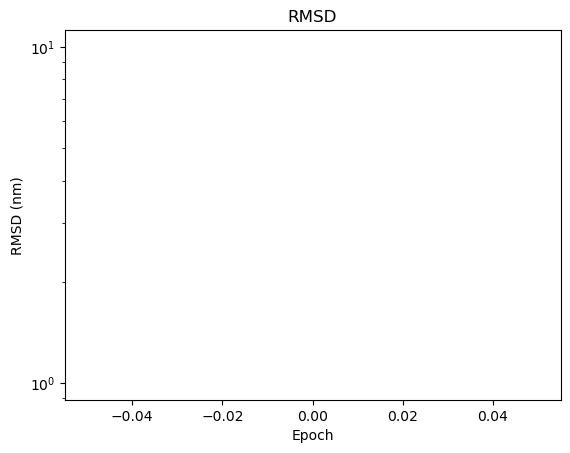

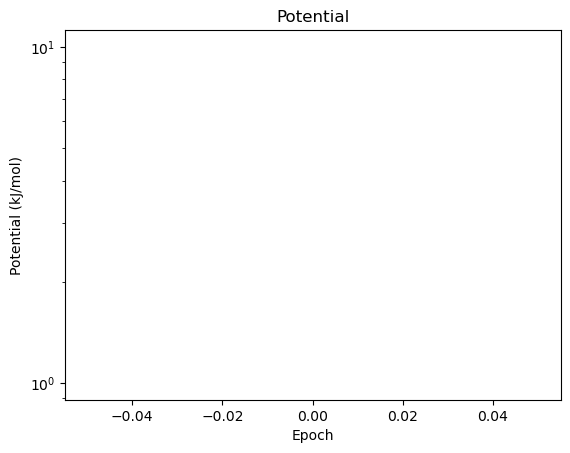

In [4]:
def plot_results(dataset):
    
    traingrp = dataset.groups['Train']
    testgrp = dataset.groups['Test']
    for foo in ['RMSD', 'Potential']:
        plt.clf()
        plt.title(foo)
        for grp in [traingrp, testgrp]:
            _ = plt.plot(np.arange(grp.variables[foo][:, :, :].shape[0]),
                         np.mean(grp.variables[foo][:, :, :], axis=(1, 2)))
        plt.xlabel('Epoch')
        plt.yscale('log')
        if foo == 'RMSD':
            plt.ylabel('RMSD (nm)')
        elif foo == 'Potential':
            plt.ylabel('Potential (kJ/mol)')
        plt.show()

plot_results(dataset)

In [6]:
orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
state = orbax_checkpointer.restore('AE_Dropout_RMSD_only/64_latents/rpt_1/checkpoint_managed/23766/default/')

In [8]:
state.apply_fn

AttributeError: 'dict' object has no attribute 'apply_fn'

### Plot the Loss

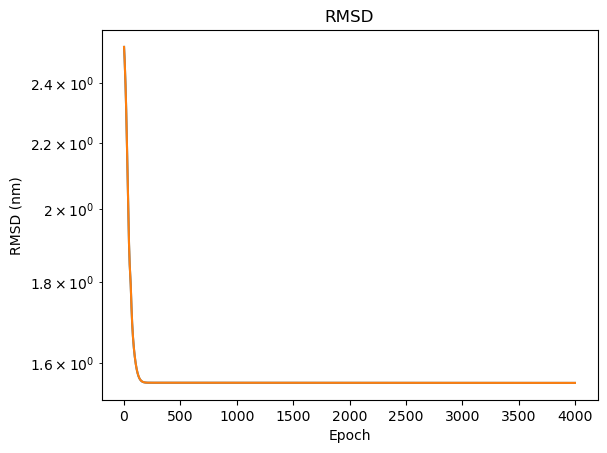

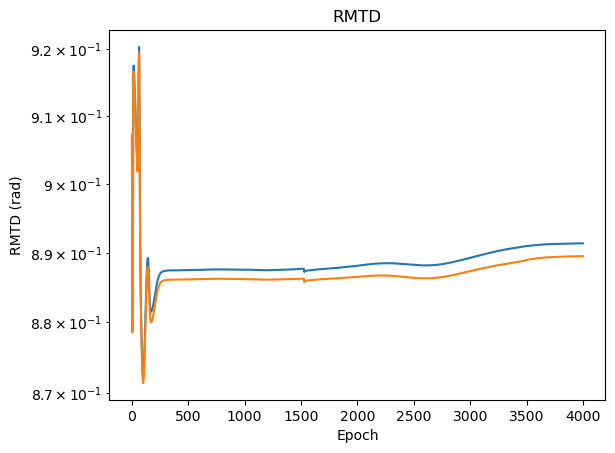

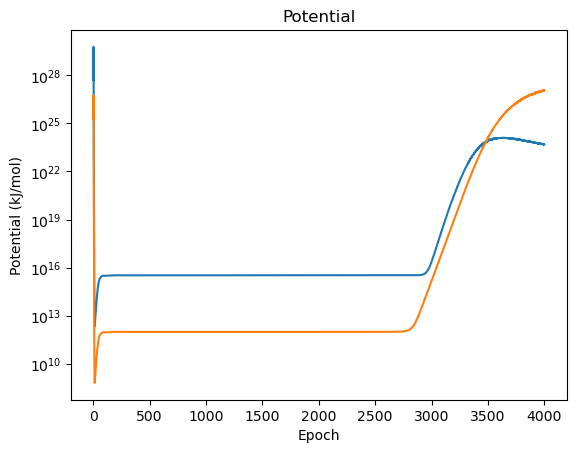

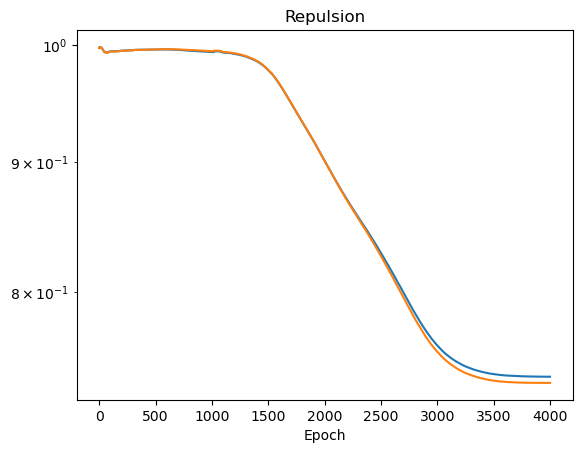

In [6]:
self.plot_losses()

### Plot the Latents

In [7]:
rng_seed = 8925
rng = jax.random.PRNGKey(rng_seed)
rng, key = jax.random.split(rng)
decoded, latent = self.state.apply_fn({'params':self.state.params}, self.test_data, rng)

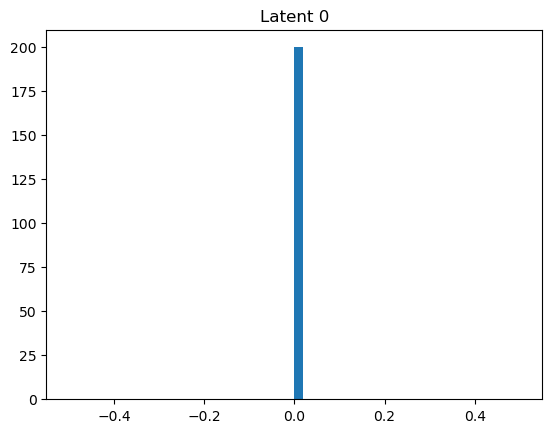

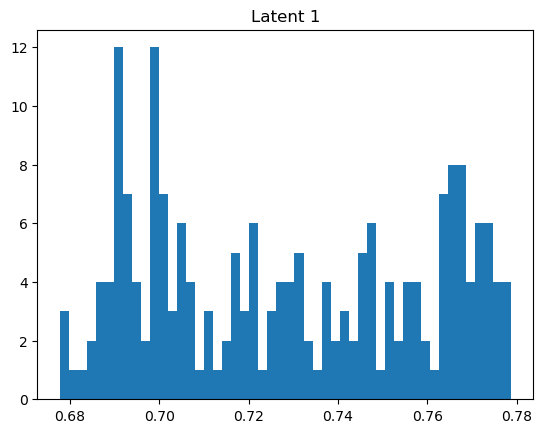

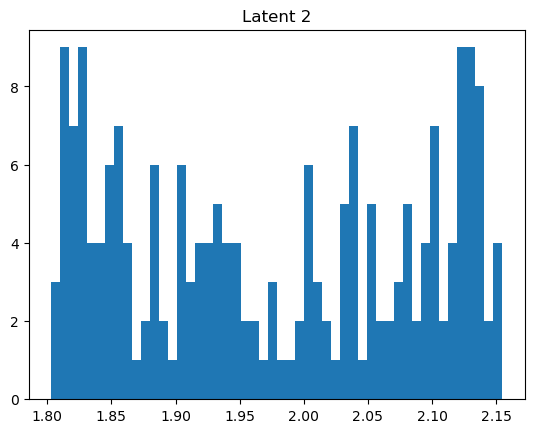

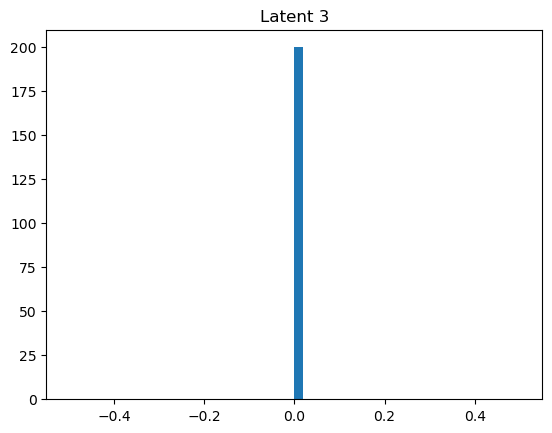

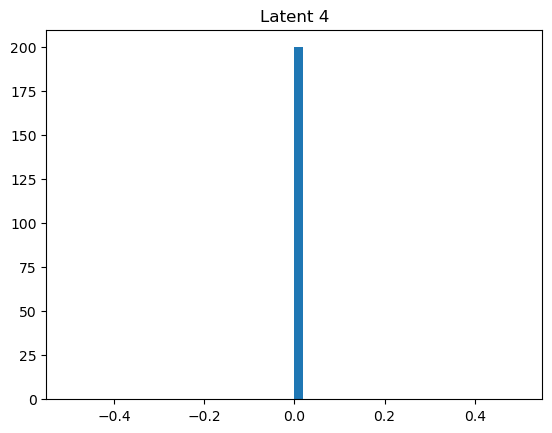

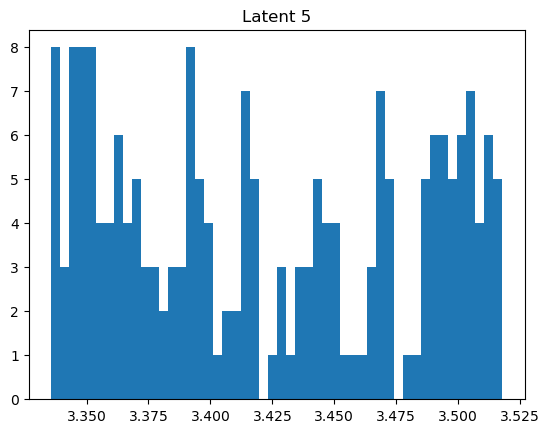

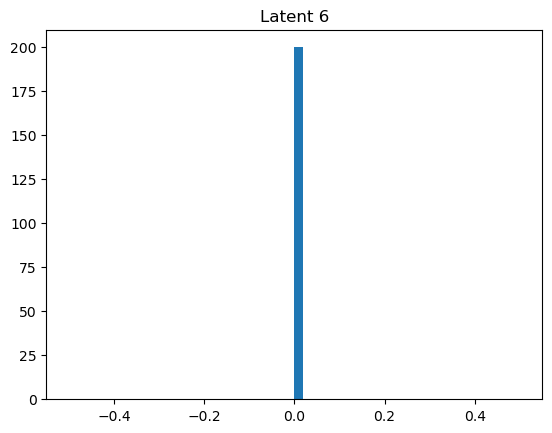

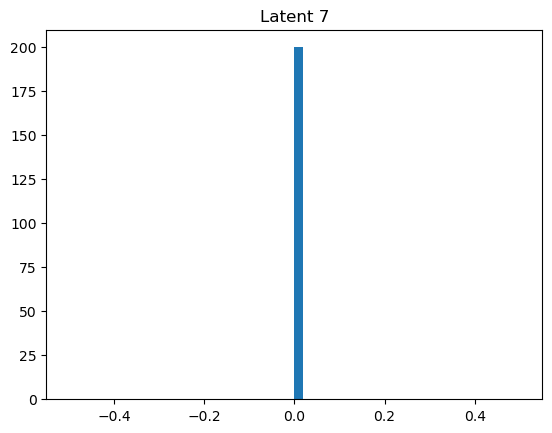

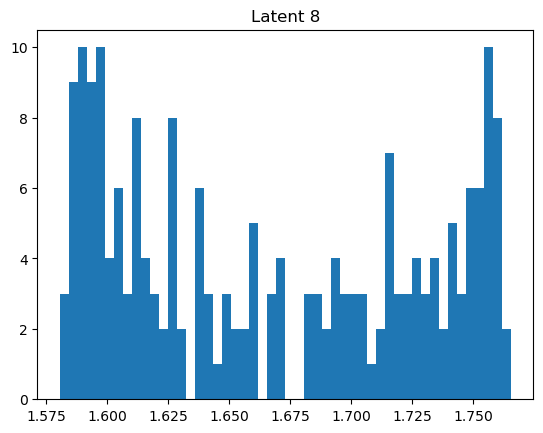

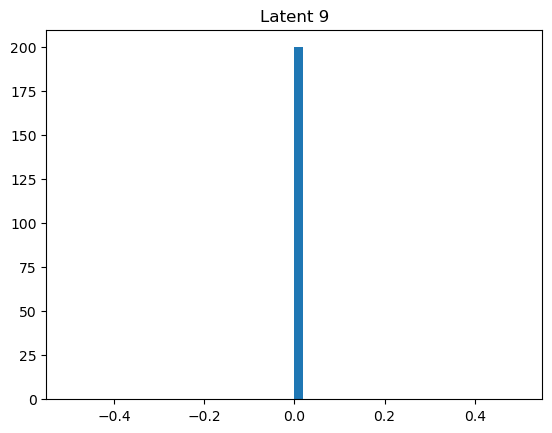

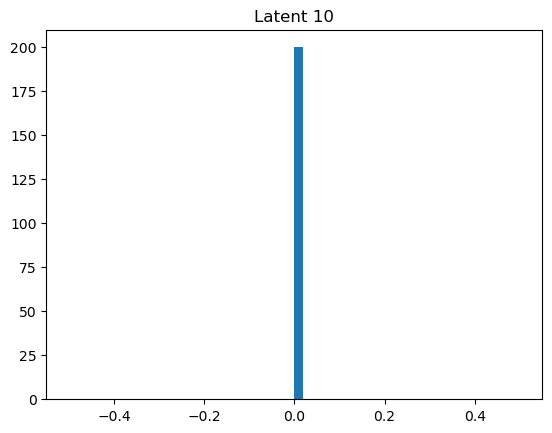

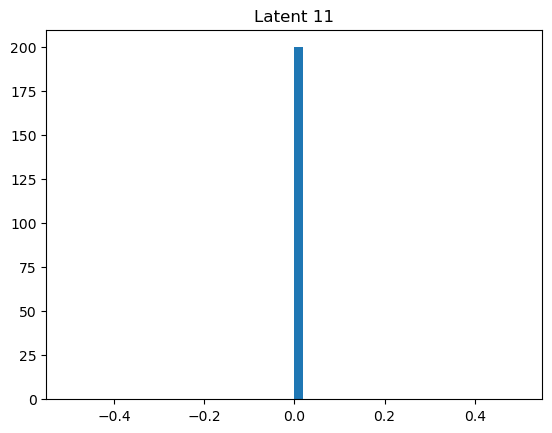

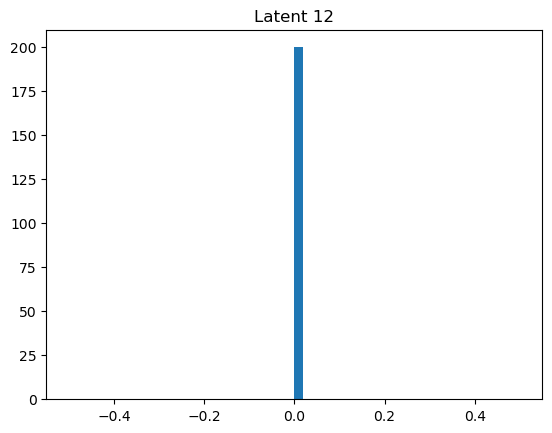

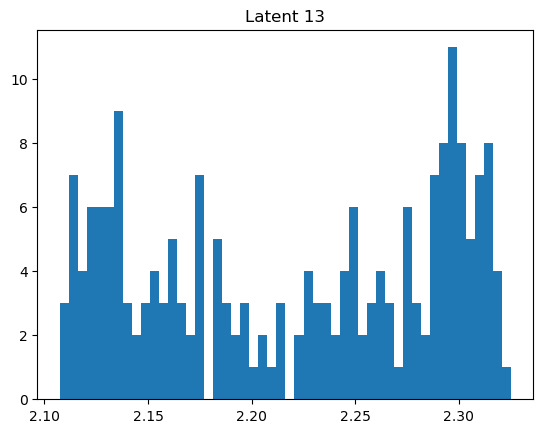

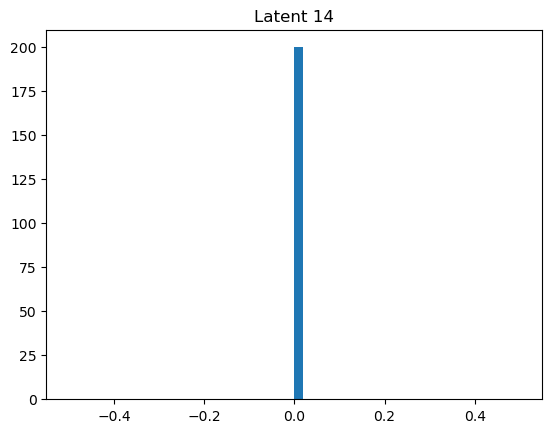

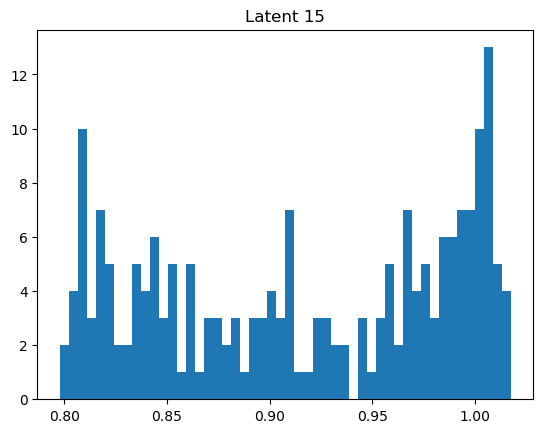

In [8]:
for i in range(self.n_latents):
    plt.clf()
    _ = plt.hist(latent[:, i], bins=50)
    plt.title(f'Latent {i}')
    plt.show()

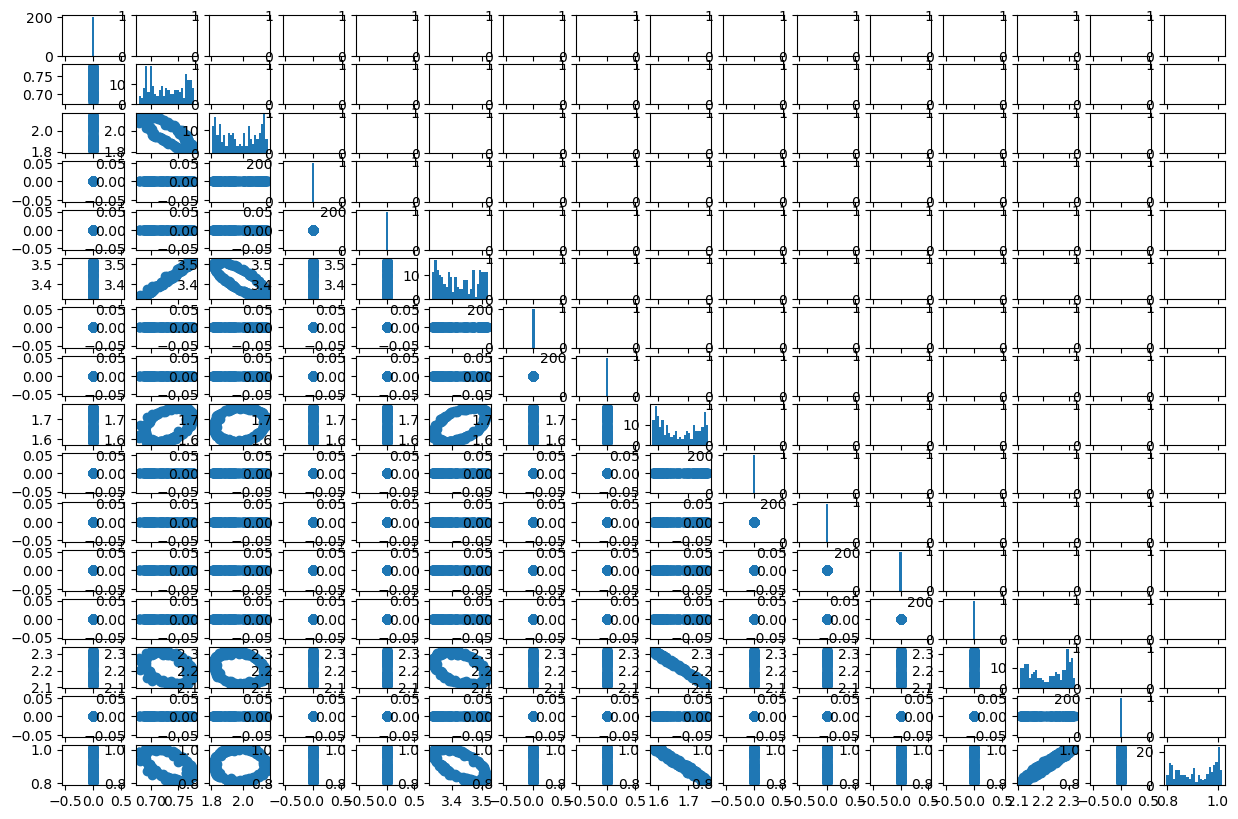

In [9]:
fig, axs = plt.subplots(self.n_latents, self.n_latents,
                        figsize=(15, 10), sharex='col')
for i in range(self.n_latents):
    for j in range(self.n_latents):
        #axs[i,j].scatter(latent[:,j], latent[:,i])
        if i > j:
            axs[i,j].scatter(latent[:,j], latent[:,i])
        elif i == j:
            axs[i,j].hist(latent[:, i], bins=25)


### Gaussian Mixture Model

In [10]:
from sklearn.mixture import GaussianMixture

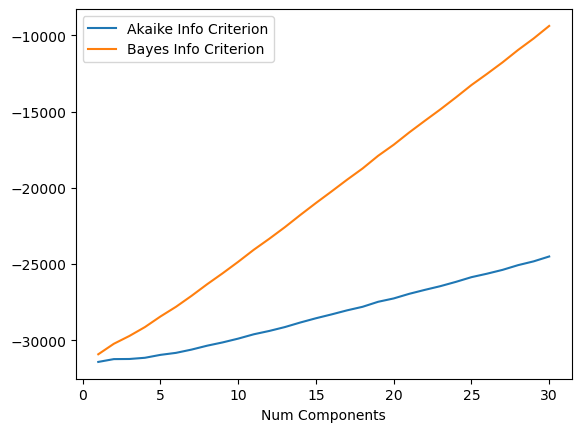

In [11]:
ics = []
X = np.array(latent)
for i in range(1, 31):
    MM = GaussianMixture(n_components=i).fit(latent)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()

In [12]:
MM = GaussianMixture(n_components=5).fit(X) #chosen based on above graph
samples = MM.sample(latent.shape[0])[0]

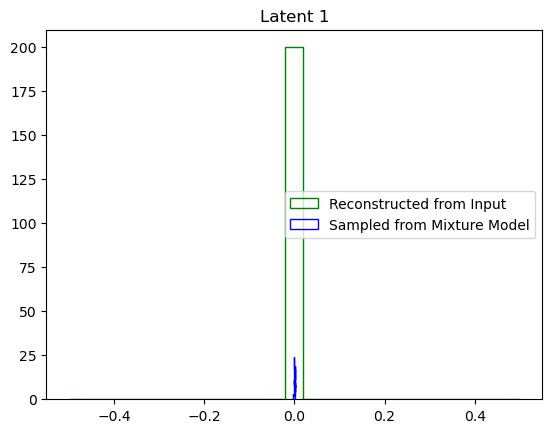

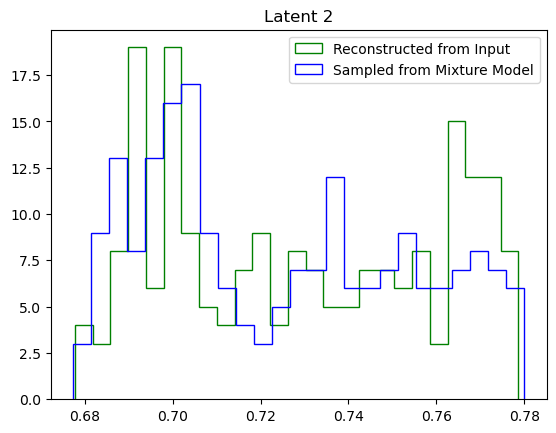

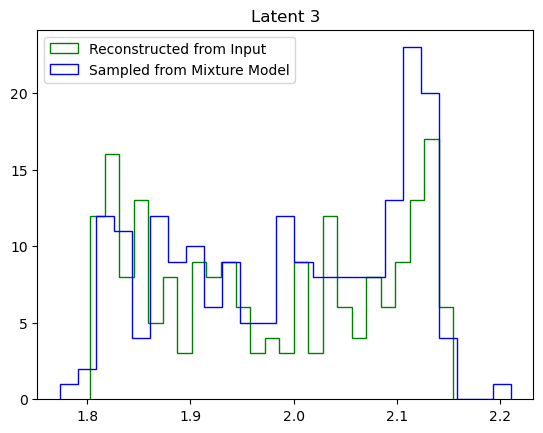

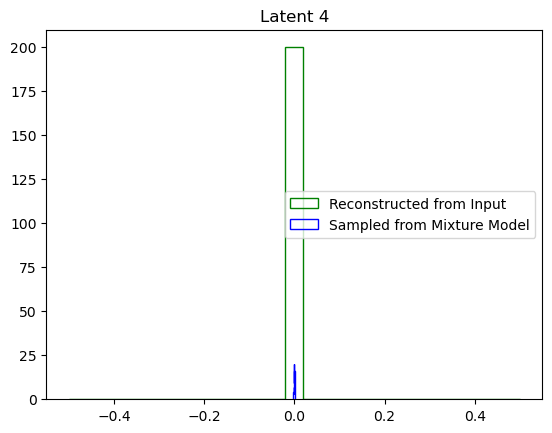

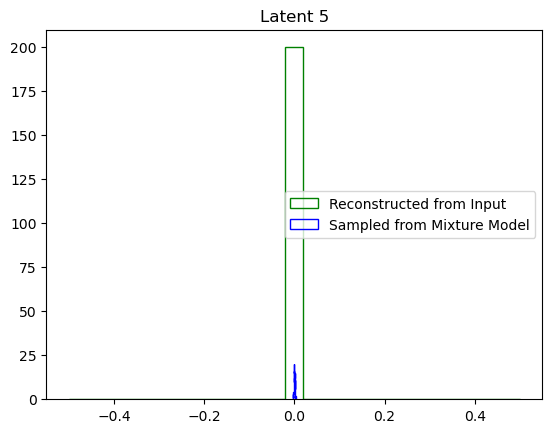

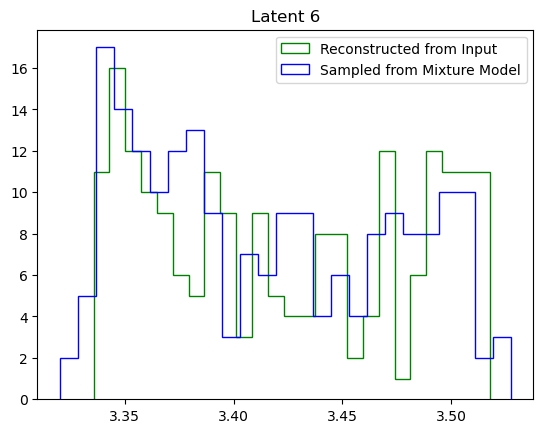

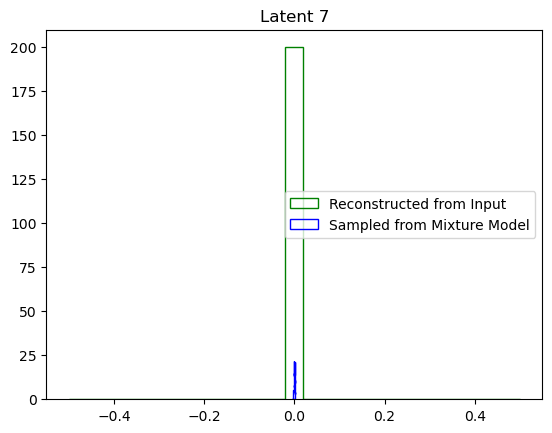

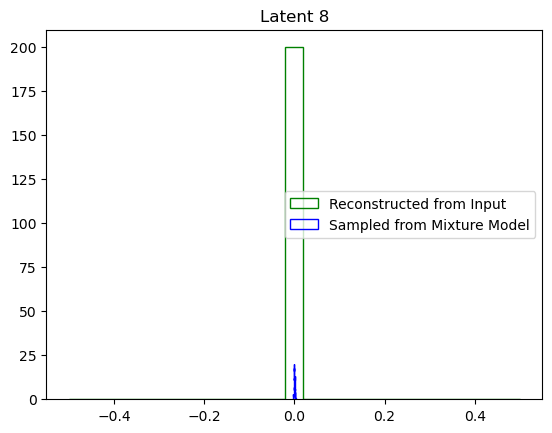

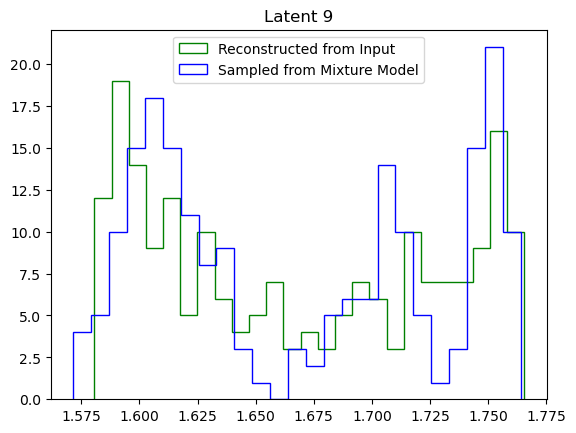

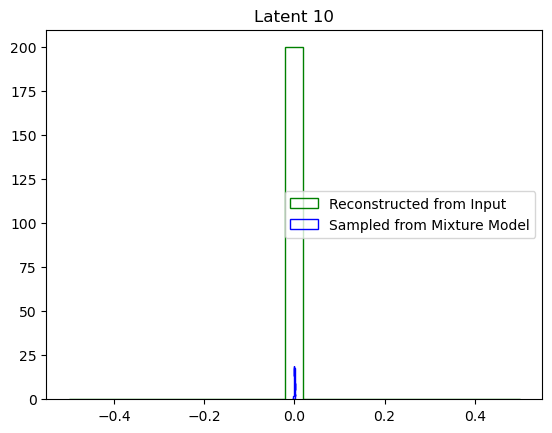

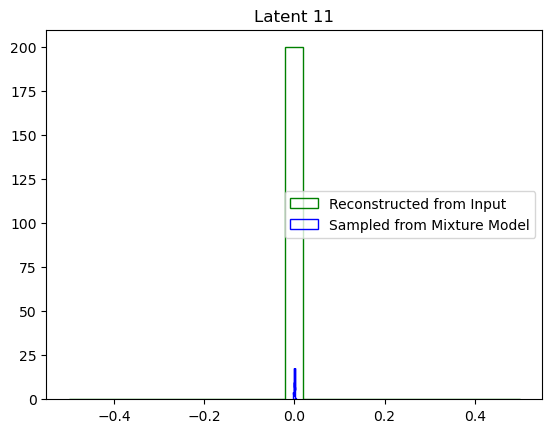

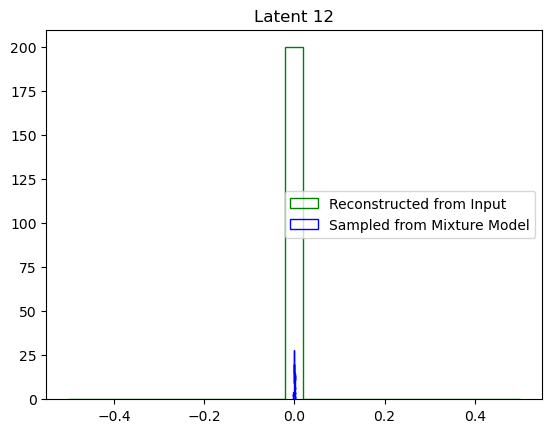

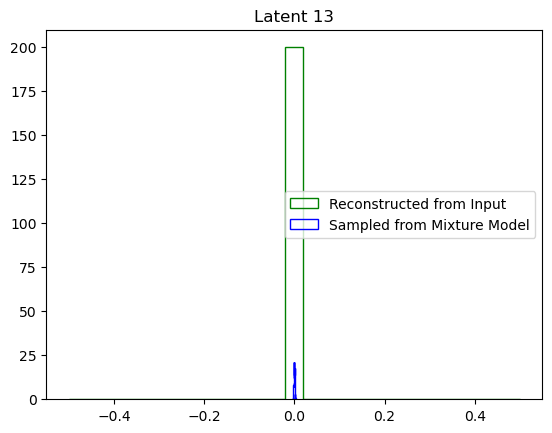

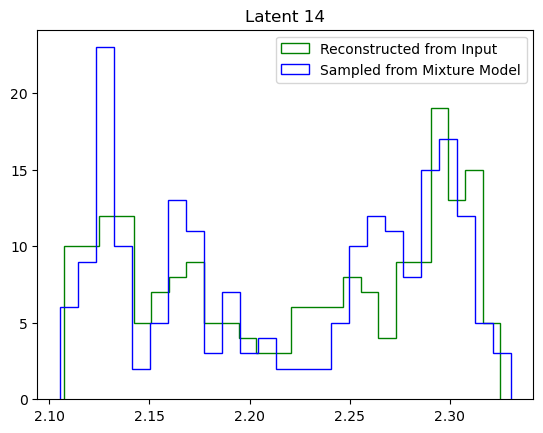

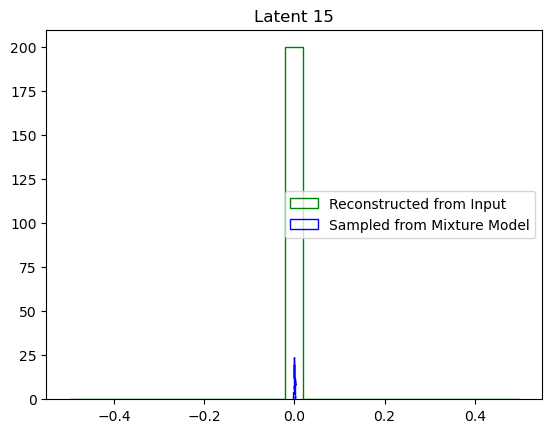

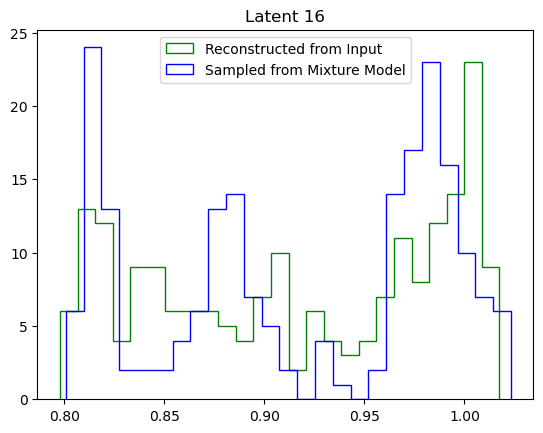

In [13]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latent[:,i], bins=25, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=25, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

### Plot Energies

In [14]:
test_ener = self.math.ener_fun(self.test_data)
decoded_ener = self.math.ener_fun(decoded)
gmm_atomistic = self.state.apply_fn({'params': self.state.params}, samples, rng, method=self.model.decode)
gmm_ener = self.math.ener_fun(gmm_atomistic)

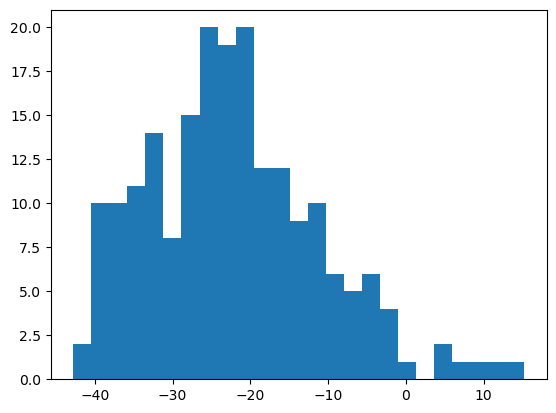

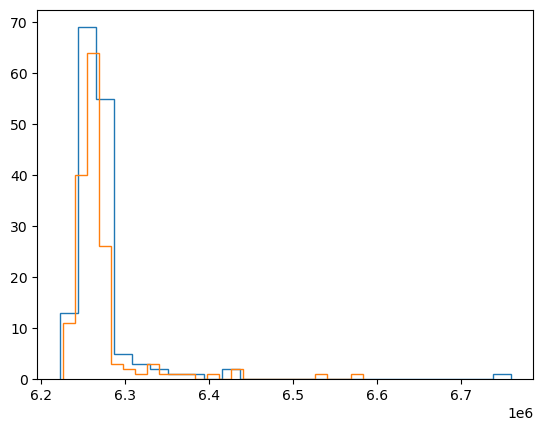

In [32]:
plt.clf()
_ = plt.hist(test_ener, bins=25)
plt.show()
thresh = 7e6
_ = plt.hist(decoded_ener[decoded_ener < thresh], bins=25, histtype='step')
_ = plt.hist(gmm_ener[gmm_ener < thresh], bins=25, histtype='step')

### Distance Matrics

#### Test Data

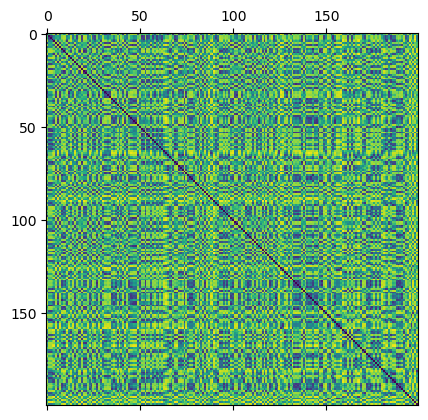

In [16]:
plt.matshow(self.math.rmsd_distance_matrix(self.test_data, self.test_data))

#### Decoded Test Data

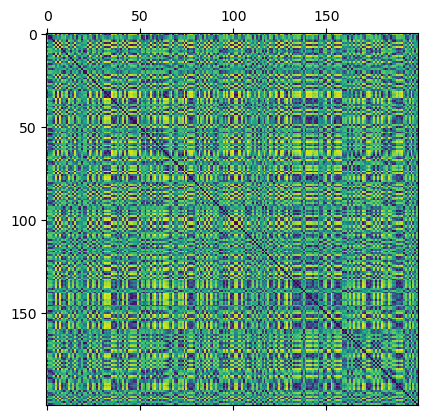

In [17]:
plt.matshow(self.math.rmsd_distance_matrix(decoded, decoded))

#### Decoded Gaussian Mixture Model

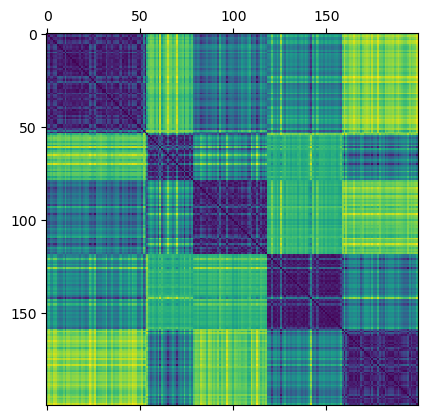

In [18]:
plt.matshow(self.math.rmsd_distance_matrix(gmm_atomistic, gmm_atomistic))